## 1. Load and Inspect the Dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

all_files = glob.glob(os.path.join('./MachineLearningCVE/' , "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df.columns = df.columns.str.strip()

print(f"Dataset Loaded. Shape: {df.shape}")
print("\nList of features: ")
print(df.columns)
print("\nValue counts for all attack types:")
print(df['Label'].value_counts())

def dynamic_grouping(label):
    l = str(label).lower()

    if 'benign' in l:
        return 'Benign'
    elif 'ddos' in l:
        return 'DDoS'
    elif 'dos' in l or 'heartbleed' in l:
        return 'DoS'
    elif 'web attack' in l or 'sql injection' in l or 'xss' in l:
        return 'Web Attack'
    elif 'patator' in l:
        return 'Brute Force'
    elif 'bot' in l:
        return 'Botnet'
    elif 'portscan' in l:
        return 'PortScan'
    elif 'infiltration' in l:
        return 'Infiltration'
    else:
        return 'Other'


df['Attack Family'] = df['Label'].apply(dynamic_grouping)

Dataset Loaded. Shape: (2830743, 79)

List of features: 
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packe


Mapping logic:
Attack Family                Benign  Botnet  Brute Force    DDoS     DoS  \
Label                                                                      
BENIGN                      2273097       0            0       0       0   
Bot                               0    1966            0       0       0   
DDoS                              0       0            0  128027       0   
DoS GoldenEye                     0       0            0       0   10293   
DoS Hulk                          0       0            0       0  231073   
DoS Slowhttptest                  0       0            0       0    5499   
DoS slowloris                     0       0            0       0    5796   
FTP-Patator                       0       0         7938       0       0   
Heartbleed                        0       0            0       0      11   
Infiltration                      0       0            0       0       0   
PortScan                          0       0            0       0       0

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/ai/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean   Fwd IAT Std   Fwd IAT Max   Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean   Bwd IAT Std   Bwd IAT Max   Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average Packet Size  Avg Fwd Segment Size  Avg Bwd Segment Size  Fwd Hea

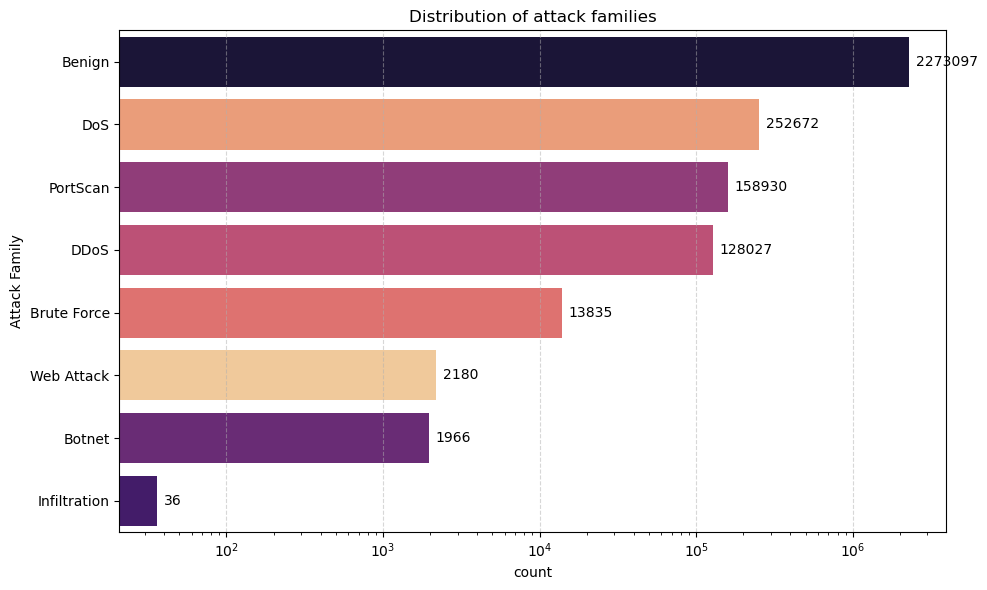


Sample rows:
         Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std   Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean   Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average Packet Size  Avg Fwd Segment Size  Avg Bwd Segment S

In [9]:
mapping_check = pd.crosstab(df['Label'], df['Attack Family'])
print("\nMapping logic:")
print(mapping_check.loc[:, (mapping_check != 0).any(axis=0)])

print("\nAttack Family target distribution:")
print(df['Attack Family'].value_counts())

print("\nSummary of the dataset:")
print(df.describe().to_string())

plt.figure(figsize=(10, 6))
order = df['Attack Family'].value_counts().index
ax = sns.countplot(y='Attack Family', data=df, order=order, palette='magma', hue='Attack Family', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha = 'left', va = 'center', xytext = (5, 0),
                textcoords = 'offset points')

plt.title('Distribution of attack families')
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nSample rows:")
print(df.sample(5).to_string())

## 2. Exploratory Data Analysis (EDA)

Total NaN values: 1358
Total infinite values: 4376

Summary statistics:
       Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean   Fwd IAT Std   Fwd IAT Max   Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean   Bwd IAT Std   Bwd IAT Max   Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  

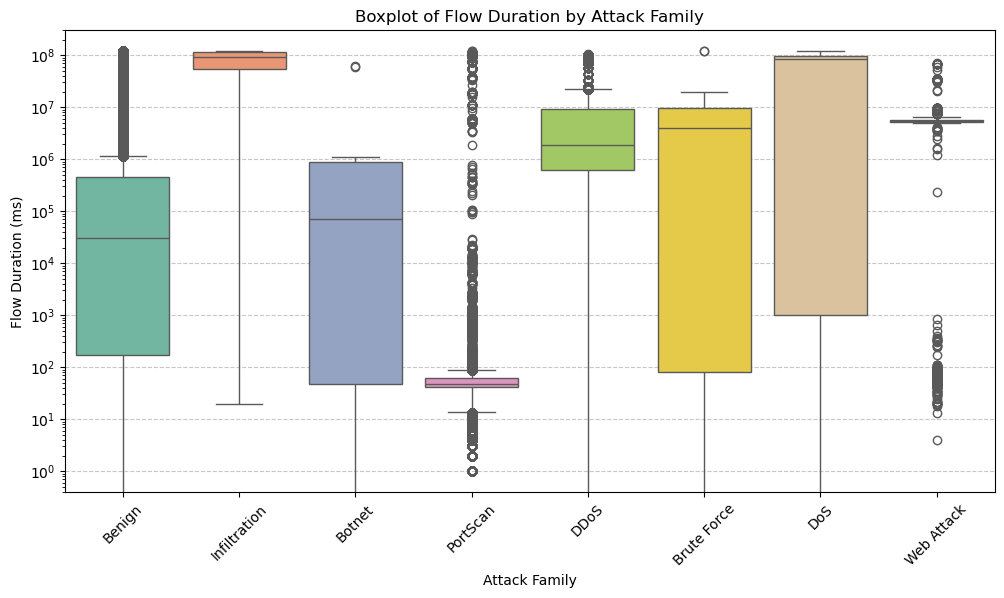

In [10]:
import numpy as np

missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()

numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
total_inf = inf_counts.sum()

print(f"Total NaN values: {total_missing}")
print(f"Total infinite values: {total_inf}")

print("\nSummary statistics:")
stats_df = df.replace([np.inf, -np.inf], np.nan)
print(stats_df.describe().to_string())

print("\nOutlier detection:")
target_col = 'Flow Duration'
clean_col = stats_df[target_col].dropna()

Q1 = clean_col.quantile(0.25)
Q3 = clean_col.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = clean_col[(clean_col < lower_bound) | (clean_col > upper_bound)]

print(f"Feature evaluated: '{target_col}'")
print(f"- Q1 (25%): {Q1:,.2f}")
print(f"- Q3 (75%): {Q3:,.2f}")
print(f"- IQR:      {IQR:,.2f}")
print(f"- Outlier thresholds: < {lower_bound:,.2f} or > {upper_bound:,.2f}")
print(f"- Total outliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

plt.figure(figsize=(12, 6))
plot_sample = stats_df

sns.boxplot(x='Attack Family', y='Flow Duration', data=plot_sample, palette='Set2', hue='Attack Family', legend=False)

plt.yscale('log')
plt.title('Boxplot of Flow Duration by Attack Family')
plt.ylabel('Flow Duration (ms)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:**
1. PortScan is fast, which confirms that port scanning involves sending many short, rapid packets to check open ports.
2. Infiltration and DoS have the highest medians, which is consistent with their nature. Infiltration maintains a persistent connection, and DoS attempts to tie up server resources for as long as possible.
3. Benign traffic has a large spread and many outliers extending upwards. This indicates that normal user traffic varies wildly, making it difficult to distinguish from attacks based on duration alone.
4. The Web Attack box is quite compressed compared to others. This suggests these attacks follow a programmed, consistent timing pattern.

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


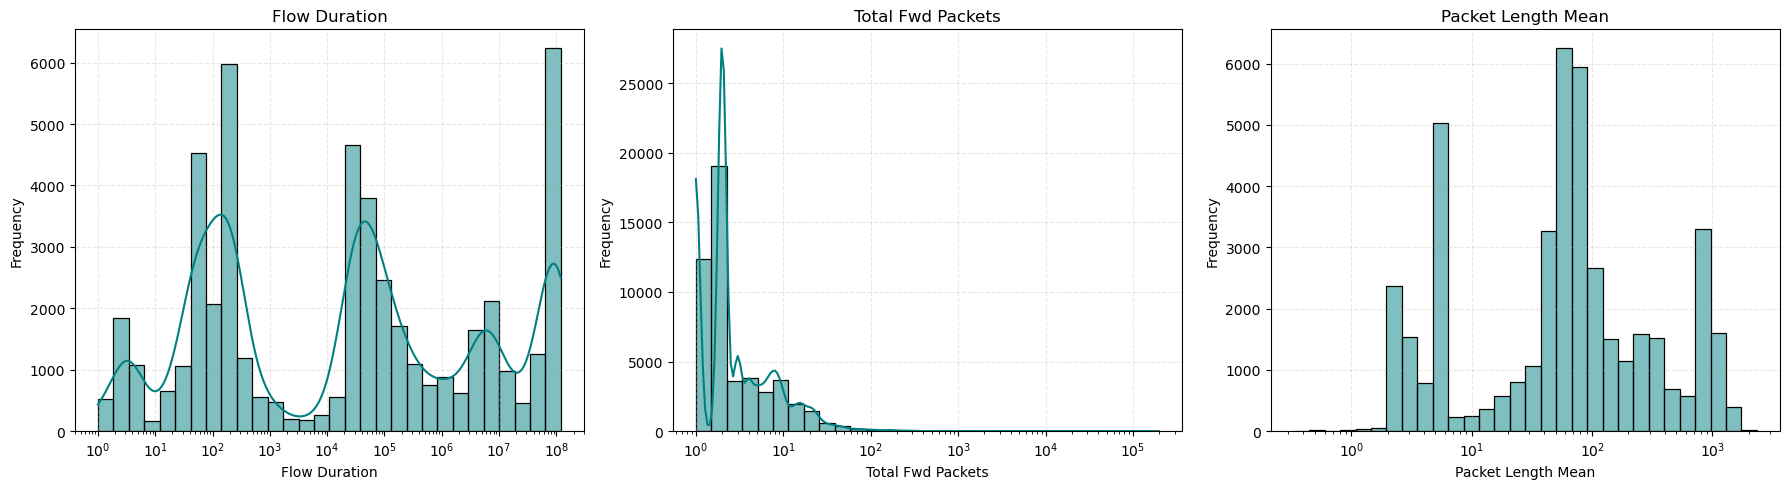

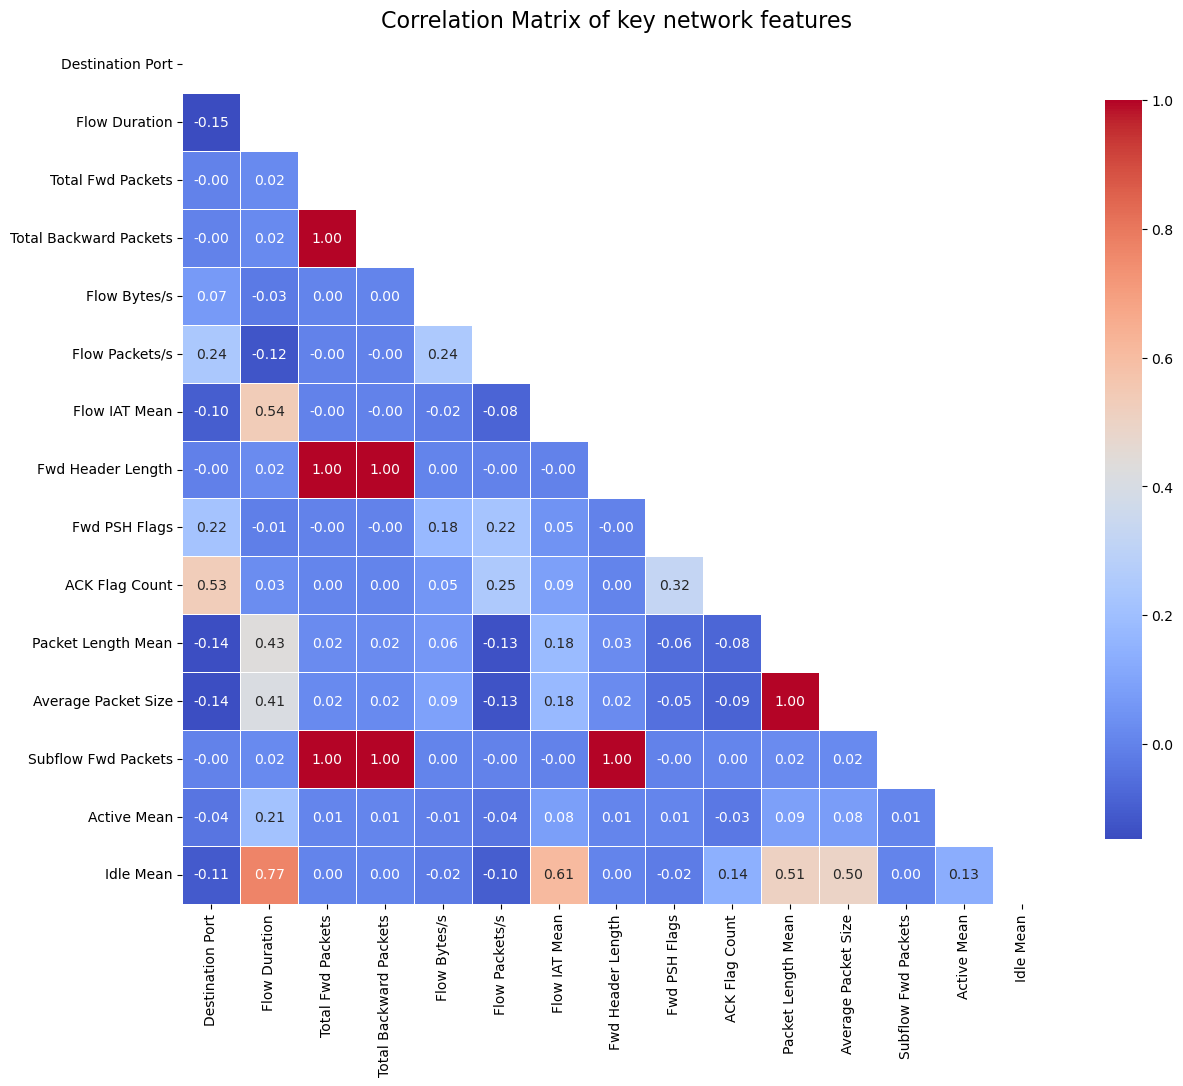

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
df_sample, _ = train_test_split(df_clean, train_size=50000,
                                stratify=df_clean['Attack Family'],
                                random_state=42)

key_features = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(key_features):
    plt.subplot(1, 3, i+1)

    sns.histplot(df_sample[feature], kde=True, bins=30, log_scale=True, color='teal')

    plt.title(f'{feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

cols_to_corr = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Fwd Header Length', 'Fwd PSH Flags',
    'ACK Flag Count', 'Packet Length Mean', 'Average Packet Size',
    'Subflow Fwd Packets', 'Active Mean', 'Idle Mean'
]

corr_matrix = df_sample[cols_to_corr].corr()

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of key network features', fontsize=16)
plt.show()

**Interpretation:**
1. Flow Duration: It shows distinct groups, like short bursts, longer connections and maximum timeouts.
2. Total Fwd Packets: This is a classic right-skewed distribution. The vast majority of flows consist of very few packets and the curve flattens but extends far to the right.
3. Packet Length Mean: The graph is jagged because network packet sizes are standardized. There are small peaks which likely represent control packets and large peaks which are packets hitting the MTU. There are few packets in between.
4. Correlation matrix: There are several features with a correlation of 1.00, meaning they contain identical information. Volume Cluster: *Total Fwd Packets*, *Total Backward Packets*, *Fwd Header Length*, and *Subflow Fwd Packets* are all perfectly correlated. Size Cluster: *Packet Length Mean* and *Average Packet Size* are perfectly correlated. We can safely drop most of these redundant features without losing any data signal.


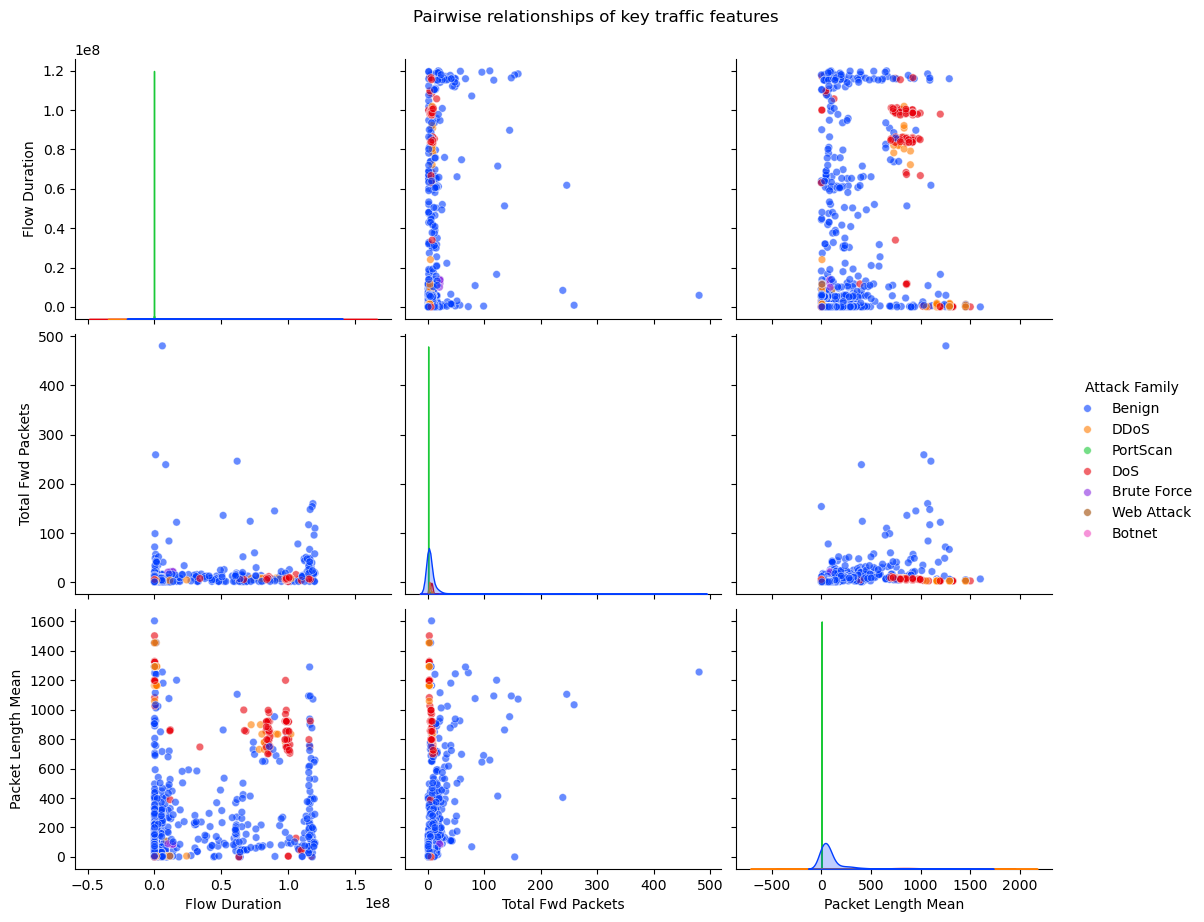

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/envs/ai/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


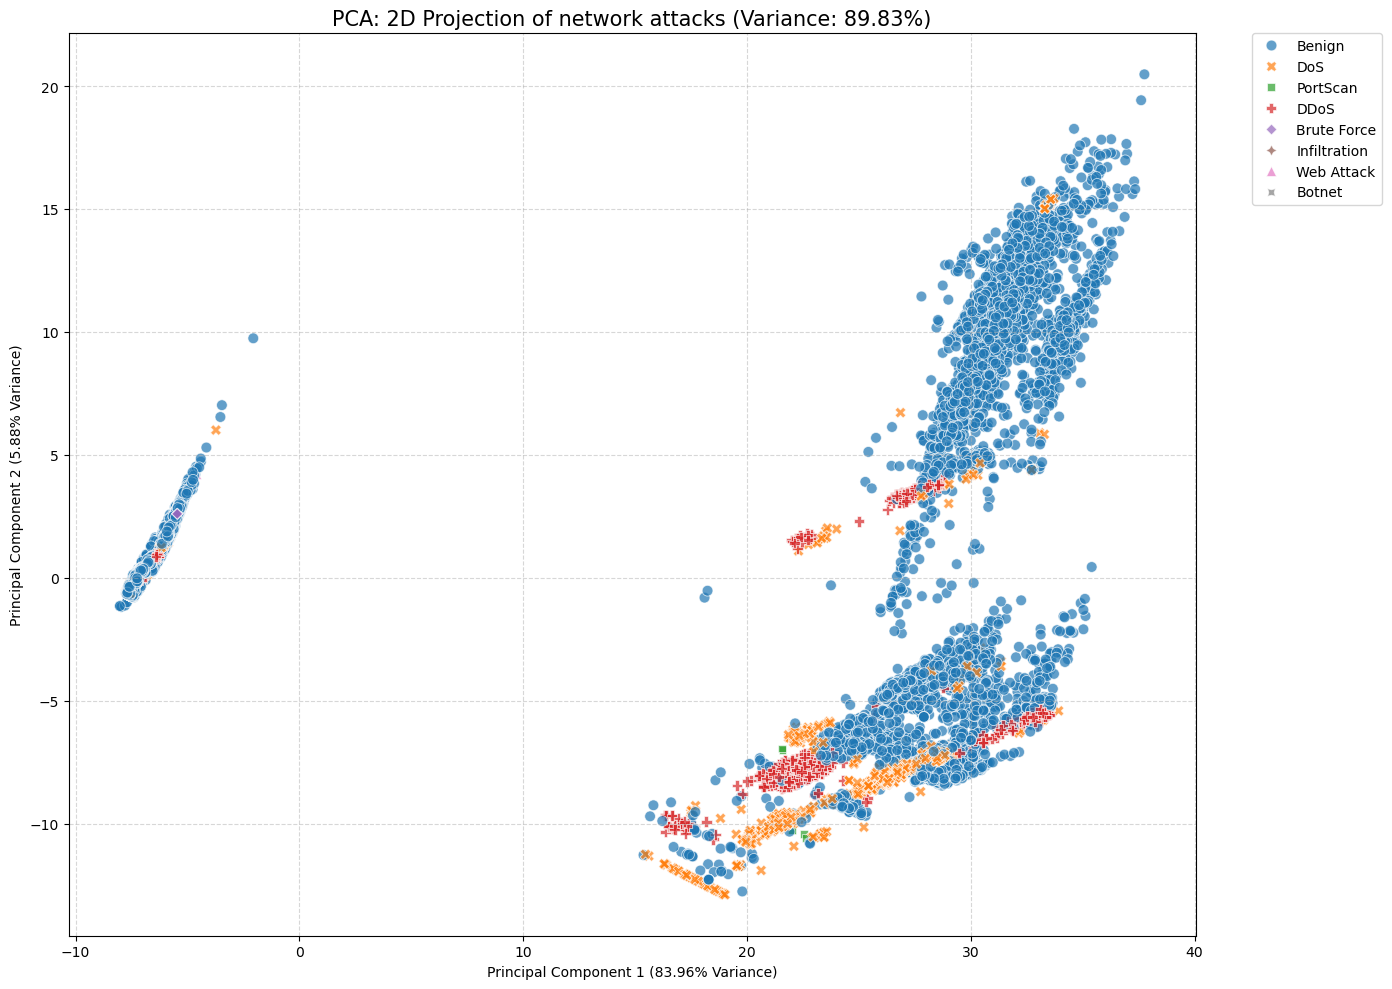

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
df_pca_sample, _ = train_test_split(df_clean, train_size=50000,
                                    stratify=df_clean['Attack Family'],
                                    random_state=42)

df_pair_sample, _ = train_test_split(df_clean, train_size=2000,
                                        stratify=df_clean['Attack Family'],
                                        random_state=42)

features_to_plot = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean']
pair_data = df_pair_sample[features_to_plot + ['Attack Family']].copy()

g = sns.pairplot(pair_data, hue='Attack Family', palette='bright',
                    height=3, aspect=1.2, plot_kws={'alpha': 0.6, 's': 30})

g.figure.suptitle('Pairwise relationships of key traffic features', y=1.02)
plt.show()

X = df_pca_sample.select_dtypes(include=[np.number])
X = X.drop(columns=['Destination Port'], errors='ignore')
y = df_pca_sample['Attack Family']

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_log = np.log1p(X)
X_log = X_log.replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Attack Family'] = y.reset_index(drop=True)

plt.figure(figsize=(14, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Attack Family', data=pca_df,
                alpha=0.7, palette='tab10', style='Attack Family', s=60)

plt.title(f'PCA: 2D Projection of network attacks (Variance: {sum(pca.explained_variance_ratio_):.2%})', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation:**
1. Pairwise relationships: PortScan (Green) is highly distinct. DoS/DDoS (Red/Orange) tend to have very high durations but relatively low packet counts. Benign (Blue) traffic is scattered everywhere.
2. PCA: The data is split into two clusters separated by a large gap. Left cluster is mostly Benign traffic with some Brute Force and DoS mixed in. Right cluster is a high-variance group containing massive Benign flows mixed with DDoS and DoS attacks. Dos and DDos attacks form distinct, straight horizontal bands or tight clusters on the right side. Benign traffic appears everywhere. Since PC1 explains 83.85% of the variance and separates the two main groups this is the single most important difference between these network flows.

Attack families are separable partially, some are easy to classify and some are very hard, and there is also the issue with the Benign traffic which overlaps pretty much all traffic data.

## 3. Data Audit and Cleaning

Before any modelling, the data is checked for problems that would make a random train/test split overly optimistic:

1. **Duplicate rows.** Repetitive attack traffic (e.g. DoS floods) produces identical flow records. A random split puts copies on both sides, so part of the test set measures memorisation.
2. **Conflicting labels.** The same feature vector can appear with different attack families; such rows are ambiguous by construction.
3. **Constant and duplicated columns.** Some CICFlowMeter features never change, and some are exact copies of others. They carry no information but can still be picked by a feature selector that is forced to return a fixed number of features.
4. **`Destination Port`.** A port identifies the attacked service rather than the attack's behaviour, so it is excluded from modelling.
5. **Possible shortcut features.** `Init_Win_bytes_forward/backward` (the TCP initial window size) depend on the sending machine's OS and tooling. In a testbed with only a few attacker machines they may identify *which machine* sent the traffic rather than *what it does*. Section 5.3 tests this.

### 3.1 Audit: duplicate rows, conflicting labels, constant and duplicated columns

In [13]:
import numpy as np
import pandas as pd

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
feature_cols = [c for c in df_clean.columns if c not in ('Label', 'Attack Family')]

# One 64-bit hash per row makes duplicate detection on 2.8M rows fast
row_hash = pd.Series(pd.util.hash_pandas_object(df_clean[feature_cols], index=False).values,
                     index=df_clean.index)

labels_per_vector = df_clean['Attack Family'].groupby(row_hash).nunique()
conflicting = row_hash.isin(labels_per_vector[labels_per_vector > 1].index)
duplicate = row_hash.duplicated(keep='first')

print(f"Rows:                               {len(df_clean):,}")
print(f"Duplicate feature vectors:          {duplicate.sum():,} ({duplicate.mean():.1%})")
print(f"Rows whose vector has >1 label:     {conflicting.sum():,}")

dup_share = duplicate.groupby(df_clean['Attack Family']).mean().sort_values(ascending=False)
print("\nShare of duplicate rows per attack family:")
print(dup_share.map('{:.1%}'.format).to_string())

# Columns with a single value, and columns that are exact copies of another column
const_cols = [c for c in feature_cols if df_clean[c].nunique(dropna=False) <= 1]

fingerprints = {}
for c in feature_cols:
    if c in const_cols:
        continue
    fp = int(pd.util.hash_pandas_object(df_clean[c], index=False).values.sum())
    fingerprints.setdefault(fp, []).append(c)
dup_cols = [c for group in fingerprints.values() if len(group) > 1
            for c in group[1:] if df_clean[c].equals(df_clean[group[0]])]

print(f"\nConstant columns ({len(const_cols)}): {const_cols}")
print(f"Duplicated columns ({len(dup_cols)}): {dup_cols}")

Rows:                               2,827,876
Duplicate feature vectors:          307,775 (10.9%)
Rows whose vector has >1 label:     6,666

Share of duplicate rows per attack family:
Attack Family
PortScan        43.2%
Brute Force     33.8%
DoS             23.1%
Benign           7.8%
Web Attack       1.7%
Botnet           0.4%
DDoS             0.0%
Infiltration     0.0%

Constant columns (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Duplicated columns (5): ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'SYN Flag Count', 'CWE Flag Count', 'Fwd Header Length.1']


### 3.2 Why duplicates matter: leakage through a random split

In [22]:
from sklearn.model_selection import train_test_split

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    df_clean[feature_cols], df_clean['Attack Family'],
    test_size=0.2, stratify=df_clean['Attack Family'], random_state=42, shuffle=True)

seen_in_train = row_hash.loc[Xn_test.index].isin(set(row_hash.loc[Xn_train.index]))
print(f"{seen_in_train.mean():.1%} of the test rows have an identical copy in the training set\n")
print("Per attack family:")
print(seen_in_train.groupby(yn_test).mean().sort_values(ascending=False).map('{:.1%}'.format).to_string())

13.4% of the test rows have an identical copy in the training set

Per attack family:
Attack Family
PortScan        58.9%
Brute Force     37.8%
DoS             23.6%
Benign           9.7%
Web Attack       1.6%
Botnet           0.8%
DDoS             0.0%
Infiltration     0.0%


### 3.3 Clean dataset

Remove duplicate rows, drop feature vectors that appear with more than one label, and drop constant columns, duplicated columns and `Destination Port`.

In [14]:
shortcut_cols = ['Init_Win_bytes_forward', 'Init_Win_bytes_backward']
drop_cols = sorted(set(const_cols) | set(dup_cols) | {'Destination Port'})
model_cols = [c for c in feature_cols if c not in drop_cols]

df_dedup = df_clean.loc[~conflicting & ~duplicate]
print(f"Rows kept: {len(df_dedup):,} of {len(df_clean):,} (removed {len(df_clean) - len(df_dedup):,})")
print(f"Features kept: {len(model_cols)} of {len(feature_cols)}; dropped: {drop_cols}")

counts = pd.DataFrame({'before': df_clean['Attack Family'].value_counts(),
                       'after': df_dedup['Attack Family'].value_counts()})
counts['kept'] = (counts['after'] / counts['before']).map('{:.1%}'.format)
display(counts)

Rows kept: 2,519,404 of 2,827,876 (removed 308,472)
Features kept: 64 of 78; dropped: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Destination Port', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length.1', 'SYN Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Packets']


,before,after,kept
Attack Family,,,
Benign,2271320,2094360,92.2%
Botnet,1956,1948,99.6%
Brute Force,13832,9150,66.2%
DDoS,128025,128011,100.0%
DoS,251723,193626,76.9%
Infiltration,36,36,100.0%
PortScan,158804,90130,56.8%
Web Attack,2180,2143,98.3%


## 4. Feature Engineering

The deduplicated data is split first (stratified 80/20), and everything that is learned from data (scaling, feature selection, PCA) is fitted on the training part only.

In [15]:
from sklearn.preprocessing import StandardScaler

X2 = df_dedup[model_cols]
y2 = df_dedup['Attack Family']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42)

print(f"Train: {len(X2_train):,} rows | Test: {len(X2_test):,} rows | Features: {len(model_cols)}")
print("\nTest rows per family:")
print(y2_test.value_counts().to_string())

Train: 2,015,523 rows | Test: 503,881 rows | Features: 64

Test rows per family:
Attack Family
Benign          418872
DoS              38725
DDoS             25602
PortScan         18026
Brute Force       1830
Web Attack         429
Botnet             390
Infiltration         7


### 4.1 Strategy A: sequential feature selection

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector

cap = 1500
sub_idx = np.concatenate([
    y2_train[y2_train == c].sample(min(cap, int((y2_train == c).sum())), random_state=42).index
    for c in y2_train.unique()
])
scaler_sfs = StandardScaler().fit(X2_train)
X2_sub = pd.DataFrame(scaler_sfs.transform(X2_train.loc[sub_idx]), columns=model_cols)
y2_sub = y2_train.loc[sub_idx].to_numpy()
print("Feature-selection sample per family:")
print(pd.Series(y2_sub).value_counts().to_string())

sfs = SequentialFeatureSelector(
    KNeighborsClassifier(n_neighbors=3),
    n_features_to_select='auto', tol=0.001, direction='forward',
    scoring='f1_macro', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1)
sfs.fit(X2_sub, y2_sub)
selected2 = [str(c) for c in np.array(model_cols)[sfs.get_support()]]
print(f"\nSelected {len(selected2)} features: {selected2}")

Feature-selection sample per family:
Benign          1500
PortScan        1500
DoS             1500
DDoS            1500
Web Attack      1500
Brute Force     1500
Botnet          1500
Infiltration      29

Selected 6 features: ['Total Fwd Packets', 'Fwd Packet Length Max', 'Bwd Packet Length Std', 'Flow IAT Max', 'Flow IAT Min', 'Init_Win_bytes_backward']


### 4.2 Strategy B: Principal Component Analysis

PCA on standardised features, keeping the components that explain 95% of the variance. Both the scaler and the PCA are fitted on the training data only.

Original features: 64
PCA components retained: 25
Explained variance ratio: 0.9576


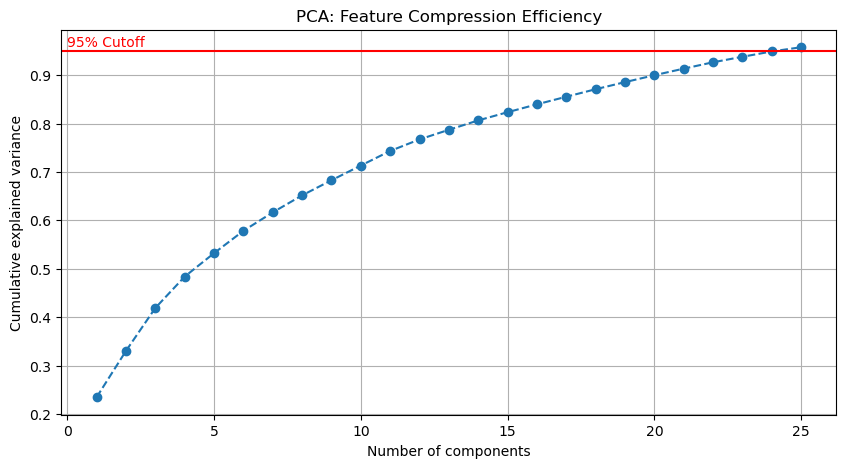

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

scaler_pca = StandardScaler().fit(X2_train)
pca = PCA(n_components=0.95).fit(scaler_pca.transform(X2_train))
X2_train_pca = pca.transform(scaler_pca.transform(X2_train))
X2_test_pca = pca.transform(scaler_pca.transform(X2_test))

print(f"Original features: {len(model_cols)}")
print(f"PCA components retained: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Feature Compression Efficiency')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0, 0.96, '95% Cutoff', color='red')
plt.show()

## 5. Multi-Class Classification Models

Three models: Decision Tree, Gaussian Naive Bayes and k-NN. On the selected features, Naive Bayes and k-NN get standardised inputs through a pipeline. Results are reported as macro F1 and per-class recall, because accuracy is dominated by Benign traffic.

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3, n_jobs=-1)),
}

# PCA components are already computed from standardised data
models_pca = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "k-NN": KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
}

def training_loop(models, X_train_use, X_test_use, y_train_use, y_test_use):
    results = []
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train_use, y_train_use)
        y_pred = model.predict(X_test_use)

        classes = list(model.classes_)
        recalls = recall_score(y_test_use, y_pred, average=None, labels=classes, zero_division=0)

        result = {
            "Model": name,
            "Accuracy": accuracy_score(y_test_use, y_pred),
            "Macro F1": f1_score(y_test_use, y_pred, average='macro'),
        }
        for cls_name, cls_recall in zip(classes, recalls):
            result[f"{cls_name} Recall"] = cls_recall
        results.append(result)

    return results

### 5.1 Strategy A: selected features

In [19]:
results_a = training_loop(models, X2_train[selected2], X2_test[selected2], y2_train, y2_test)
results_a_df = pd.DataFrame(results_a).set_index("Model")
display(results_a_df.style.highlight_max(color='green', axis=0))


Training Decision Tree...

Training Naive Bayes...

Training k-NN...


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Decision Tree,0.997065,0.878592,0.998506,0.520513,0.972678,0.998477,0.987786,0.714286,0.998669,0.818182
Naive Bayes,0.301533,0.245813,0.188256,0.030769,0.771038,0.774549,0.870368,0.428571,0.984744,0.862471
k-NN,0.996648,0.765413,0.998245,0.507692,0.974317,0.998828,0.989103,0.000000,0.998502,0.466200


### 5.2 Strategy B: PCA components

In [20]:
results_b = training_loop(models_pca, X2_train_pca, X2_test_pca, y2_train, y2_test)
results_b_df = pd.DataFrame(results_b).set_index("Model")
display(results_b_df.style.highlight_max(color='green', axis=0))


Training Decision Tree...

Training Naive Bayes...

Training k-NN...


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Decision Tree,0.998236,0.869889,0.998899,0.766667,0.975410,0.998320,0.994422,0.285714,0.999445,0.958042
Naive Bayes,0.341733,0.267496,0.257823,0.374359,0.966667,0.558863,0.776785,0.285714,0.972040,0.862471
k-NN,0.998472,0.881749,0.999071,0.776923,0.970492,0.999024,0.995378,0.285714,0.999612,0.944056


### 5.3 What each correction changes (Decision Tree)

Each row changes one thing, so the effect of the duplicates, of the cleaned feature set and of the possible shortcut features can be read separately.

In [23]:
from sklearn.metrics import classification_report

ORIGINAL_FEATURES = [
    'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std',
    'Bwd Packet Length Std', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Fwd Header Length', 'Bwd Header Length', 'FIN Flag Count', 'RST Flag Count',
    'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length.1',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
    'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Fwd IAT Min',
    'ACK Flag Count',
]
print("Constant or duplicated columns among them:",
      sorted(set(ORIGINAL_FEATURES) & (set(const_cols) | set(dup_cols))))

def dt_scores(cols, X_tr, X_te, y_tr, y_te):
    model = DecisionTreeClassifier(random_state=42).fit(X_tr[cols], y_tr)
    pred = model.predict(X_te[cols])
    return f1_score(y_te, pred, average='macro'), pred

original_cleaned = [c for c in ORIGINAL_FEATURES if c in model_cols]
experiments = [
    ("Random split with duplicates, 28 features", ORIGINAL_FEATURES, Xn_train, Xn_test, yn_train, yn_test),
    ("Deduplicated split, previous features (cleaned)",              original_cleaned,  X2_train, X2_test, y2_train, y2_test),
    ("Deduplicated split, re-selected features",                     selected2,         X2_train, X2_test, y2_train, y2_test),
]
for name, cols, *_ in list(experiments):
    if name.startswith("Deduplicated") and set(shortcut_cols) & set(cols):
        experiments.append((name + " without Init_Win_bytes",
                            [c for c in cols if c not in shortcut_cols],
                            X2_train, X2_test, y2_train, y2_test))

summary_rows, preds = [], {}
for name, cols, X_tr, X_te, y_tr, y_te in experiments:
    f1, pred = dt_scores(cols, X_tr, X_te, y_tr, y_te)
    summary_rows.append({"Experiment": name, "Features": len(cols), "Macro F1": round(f1, 3)})
    preds[name] = (y_te, pred)

display(pd.DataFrame(summary_rows).set_index("Experiment"))

y_true, y_pred = preds["Deduplicated split, re-selected features"]
print("\nPer-class report, Decision Tree on the deduplicated split with re-selected features:")
print(classification_report(y_true, y_pred, digits=3))

Constant or duplicated columns among them: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length.1']


,Features,Macro F1
Experiment,,
"Random split with duplicates, 28 features",28,0.955
"Deduplicated split, previous features (cleaned)",18,0.949
"Deduplicated split, re-selected features",6,0.879
"Deduplicated split, previous features (cleaned) without Init_Win_bytes",16,0.879
"Deduplicated split, re-selected features without Init_Win_bytes",5,0.799



Per-class report, Decision Tree on the deduplicated split with re-selected features:
              precision    recall  f1-score   support

      Benign      0.998     0.999     0.998    418872
      Botnet      0.707     0.521     0.600       390
 Brute Force      0.992     0.973     0.982      1830
        DDoS      0.998     0.998     0.998     25602
         DoS      0.993     0.988     0.991     38725
Infiltration      0.625     0.714     0.667         7
    PortScan      0.992     0.999     0.995     18026
  Web Attack      0.778     0.818     0.798       429

    accuracy                          0.997    503881
   macro avg      0.885     0.876     0.879    503881
weighted avg      0.997     0.997     0.997    503881



## 6. Monte-Carlo Cross-Validation (MCCV)

100 repetitions on stratified 6.25% subsamples of the deduplicated data with the Strategy A features, each split 70/30.

In [25]:
from tqdm import tqdm
from sklearn.base import clone

X_full = pd.concat([X2_train[selected2], X2_test[selected2]], axis=0)
y_full = pd.concat([y2_train, y2_test], axis=0)

def stratified_subsample(y, frac, min_per_class, seed):
    # Stratified sample of `frac` of the rows, with at least `min_per_class` rows per class
    parts = []
    for _, members in y.groupby(y):
        n = min(len(members), max(min_per_class, int(round(frac * len(members)))))
        parts.append(members.sample(n=n, random_state=seed).index)
    return np.concatenate(parts)

results_mccv = []
for i in tqdm(range(100), desc="MCCV Progress"):
    idx = stratified_subsample(y_full, frac=0.0625, min_per_class=5, seed=i)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_full.loc[idx], y_full.loc[idx], test_size=0.3, stratify=y_full.loc[idx], random_state=i)

    for name, template in models.items():
        model = clone(template)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        classes = list(model.classes_)
        recalls = recall_score(y_te, y_pred, average=None, labels=classes, zero_division=0)

        result_entry = {
            "Iteration": i,
            "Model": name,
            "Accuracy": accuracy_score(y_te, y_pred),
            "Macro F1": f1_score(y_te, y_pred, average='macro'),
        }
        for cls_name, cls_recall in zip(classes, recalls):
            result_entry[f"{cls_name} Recall"] = cls_recall
        results_mccv.append(result_entry)

df_results = pd.DataFrame(results_mccv).fillna(0)

MCCV Progress: 100%|██████████| 100/100 [02:41<00:00,  1.62s/it]


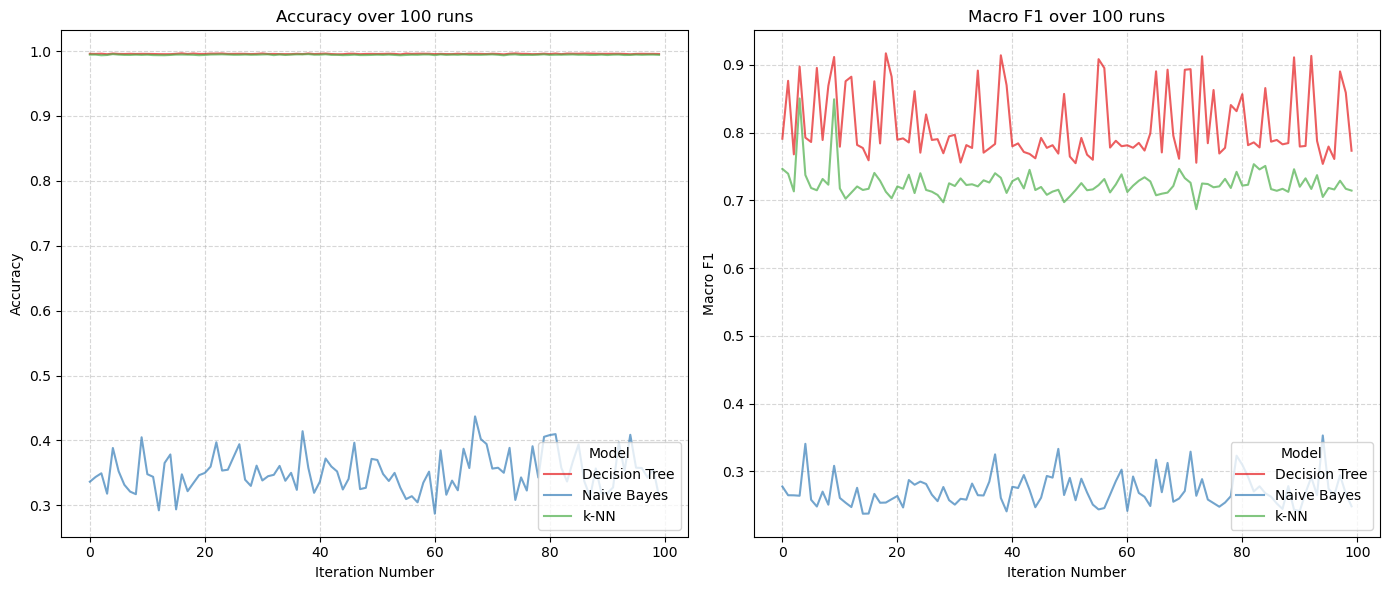


MCCV statistical summary:


Accuracy            Macro F1           Benign Recall            \
                   mean       std      mean       std          mean       std   
Model                                                                           
Decision Tree  0.995711  0.000338  0.811612  0.051209      0.997471  0.000275   
Naive Bayes    0.351289  0.030205  0.271536  0.023627      0.243145  0.033344   
k-NN           0.994367  0.000383  0.724987  0.021753      0.996739  0.000297   

              Botnet Recall           Brute Force Recall            \
                       mean       std               mean       std   
Model                                                                
Decision Tree      0.477297  0.089780           0.969651  0.013339   
Naive Bayes        0.232162  0.202000           0.780058  0.116690   
k-NN               0.492703  0.092901           0.970872  0.012271   

              DDoS Recall           DoS Recall           Infiltration Recall  \
                     mean       std       mean       std                mean   
Model                                                                          
Decision Tree    0.996896  0.001257   0.985285  0.002095                0.32   
Naive Bayes      0.859638  0.098370   0.866197  0.010053                0.58   
k-NN             0.996083  0.001463   0.982302  0.002499                0.02   

                        PortScan Recall           Web Attack Recall            
                    std            mean       std              mean       std  
Model                                                                          
Decision Tree  0.468826        0.996396  0.002069           0.72275  0.086391  
Naive Bayes    0.496045        0.983207  0.002962           0.84250  0.055448  
k-NN           0.140705        0.994864  0.002402           0.22600  0.066374

In [26]:
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_results, x="Iteration", y="Accuracy", hue="Model",
             palette="Set1", alpha=0.7, linewidth=1.5)
plt.title("Accuracy over 100 runs")
plt.ylabel("Accuracy")
plt.xlabel("Iteration Number")
plt.legend(title="Model", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
sns.lineplot(data=df_results, x="Iteration", y="Macro F1", hue="Model",
             palette="Set1", alpha=0.7, linewidth=1.5)
plt.title("Macro F1 over 100 runs")
plt.ylabel("Macro F1")
plt.xlabel("Iteration Number")
plt.legend(title="Model", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

summary = df_results.groupby("Model")[["Accuracy", "Macro F1"] + [f"{c} Recall" for c in classes]].agg(['mean', 'std'])
print("\nMCCV statistical summary:")
display(summary)

## 7. Hyperparameter Tuning

Randomised search over Decision Tree hyperparameters with 3-fold cross-validation on the training set, scored by macro F1. The tuned and untuned trees are then compared once on the test set.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

X_tr_sel, X_te_sel = X2_train[selected2], X2_test[selected2]

param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 20),
    'max_features': [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_tr_sel, y2_train)
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV macro F1: {random_search.best_score_:.4f}")

base_model = DecisionTreeClassifier(random_state=42).fit(X_tr_sel, y2_train)
y_pred_base = base_model.predict(X_te_sel)

tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_te_sel)


def get_metrics(model, y_true, y_pred, name):
    classes = list(model.classes_)
    recalls = recall_score(y_true, y_pred, average=None, labels=classes, zero_division=0)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average='macro'),
    }
    for cls_name, cls_recall in zip(classes, recalls):
        result[f"{cls_name} Recall"] = cls_recall

    return result


results = [
    get_metrics(base_model, y2_test, y_pred_base, "Base Decision Tree"),
    get_metrics(tuned_model, y2_test, y_pred_tuned, "Tuned Decision Tree")
]

df_tuning = pd.DataFrame(results).set_index("Model")
print("\nBase model vs. Tuned model comparison:")
display(df_tuning.style.highlight_max(color='green', axis=0))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters Found: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best CV macro F1: 0.8784

Base model vs. Tuned model comparison:


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Base Decision Tree,0.997065,0.878592,0.998506,0.520513,0.972678,0.998477,0.987786,0.714286,0.998669,0.818182
Tuned Decision Tree,0.997067,0.891680,0.998510,0.525641,0.975410,0.998320,0.987915,0.714286,0.998613,0.799534
